# Cluster analysis with K-means

##### Imports i definició de l'EDO de Duffing

Algorisme de l'article [Spectral-clustering approach to Lagrangian vortex detection](https://arxiv.org/pdf/1506.02258) a partir de trajectòries del sistema dinàmic donat 
pel següent sistema d'EDOs, on $f(t)=sin(t)$.
$$x'=y + \epsilon f(t)$$ $$y'=x-x^3$$

In [963]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..')) 

from src import (edo_duffing, generar_malla_condicions_inicials, 
generar_trajectories, calcula_matriu_pesos, sparcify, 
grafica_trajectories, grafica_clusters, imprimeix_estadistics, 
calcula_matriu_grau, calcula_vaps_veps, calcula_num_clusters)

import matplotlib.pyplot as plt
import numpy as np
import scipy
from sklearn.cluster import KMeans
from typing import Tuple, Iterable
from datetime import datetime
np.set_printoptions(precision=3, suppress=True)

In [933]:
def edo_duffing(t, z, random, epsilon, funcio_soroll):
    """Paràmetres:
        t: temps
        z: posició al pla R^2
        random: nombre real aleatori entre 0 i 2
        epsilon: paràmetre entre 0 i 1 que regula el soroll
        funcio_soroll: pertorbació que depèn del temps
    Retorna el camp vectorial del sistema d'EDOs x'=y+epsilon*random*f(t); y'=x-x^3.
    """
    x, y = z
    soroll = epsilon *  random * funcio_soroll(t)
    return [y + soroll, x - x**3]

##### Paràmetres

In [934]:
epsilon = 0
funcio_soroll = np.sin
dimensio = 2
t_span = (0, 4*np.pi)
t_steps = 400
t_valors = np.linspace(t_span[0], t_span[1], t_steps)
x_min, x_max = (-1.6, 1.6)
y_min, y_max = (-1, 1)
espai_entre_punts_malla = 0.05
constant_diagonal = 1000
max_clusters = 40

### Gràfiques

In [935]:
# Paràmetres
radi = 0.3
centre_esquerre = (-1, 0)
centre_dret = (1, 0)
centre_nord = (0, 1)
centre_sud = (0, -1)
resolucio_grafica = 2000

In [936]:
def grafica_circumferencia(centre: Tuple[float, float],
                           radi: float, 
                           nom_regio:str,
                           resolucio: int) -> None:
    theta = np.linspace(0, 2*np.pi, resolucio)
    a, b = centre
    xx = radi*np.cos(theta) + a
    yy = radi*np.sin(theta)
    plt.plot(xx, yy + b, 'black')
    plt.plot(xx, - yy + b, 'black')
    plt.annotate(nom_regio, centre)

def grafica_regio(nom_regio: str, radi: float, centres: list[Tuple[float, float]], resolucio: int
                  ) -> None:
    for centre in centres:
        grafica_circumferencia(centre, radi, nom_regio, resolucio)

def grafica_regions_A_B(radi: float, resolucio: int) -> None:
    grafica_regio('A', radi, [centre_esquerre, centre_dret], resolucio)
    grafica_regio('B', radi, [centre_nord, centre_sud], resolucio)

In [937]:
def grafica_trajectories(trajectories: np.ndarray,
                         dibuixa_regions: bool = False,
                         desa_pdf: bool = False, 
                         radi: float = radi, 
                         resolucio: int = resolucio_grafica
                         ) -> None:
    if dibuixa_regions: grafica_regions_A_B(radi, resolucio)
    for trajectoria in trajectories:
        coordenades_x = trajectoria[:,0]
        coordenades_y = trajectoria[:,1]
        plt.plot(coordenades_x, coordenades_y)
    for trajectoria in trajectories:
        coordenades_x = trajectoria[:,0]
        coordenades_y = trajectoria[:,1]
        pos_inicial = (coordenades_x[0], coordenades_y[0])
        inici_string = f'Inici = ({pos_inicial[0]:.2f}, {pos_inicial[1]:.2f})'
        plt.plot(pos_inicial[0], pos_inicial[1], '-o', label=inici_string, color='grey')
        pos_final = (coordenades_x[-1], coordenades_y[-1])
        final_string = f'Final = ({pos_final[0]:.2f}, {pos_final[1]:.2f})'
        plt.plot(pos_final[0], pos_final[1], '-o', label=final_string, color='red')
    plt.xlabel('x')
    plt.ylabel('y') 
    # plt.legend(); 
    plt.grid()
    plt.gca().set_aspect('equal', adjustable='box')
    # plt.gca().set_xlim(-10, 10)
    if desa_pdf: plt.savefig('edo.pdf')
    plt.show()

In [938]:
def grafica_punts(punts: Iterable, dibuixa_regions=False, radi=radi, resolucio=resolucio_grafica) -> None:
    """punts: conjunt de punts a R^2. Exemple: [[0,1], [0.5,1], [1,1]]"""
    if dibuixa_regions:
        grafica_regions_A_B(radi, resolucio)
    for punt in punts:
        plt.plot(punt[0], punt[1], 'o', markersize=5, color="grey")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Condicions inicials')
    plt.grid()
    plt.gca().set_aspect('equal')
    plt.show()

In [939]:
def grafica_clusters(condicions_inicials, labels, args) -> None:
    num_clusters, sparsification_tol, sparsification_percent, t_steps, t_span = args
    num_trajectories = len(condicions_inicials)
    for cluster_id in range(num_clusters):
        indices = np.where(labels == cluster_id)
        if len(indices[0]) > 0:
            plt.scatter(condicions_inicials[indices, 0], 
                        condicions_inicials[indices, 1], 
                        s=60, label=cluster_id)
    plt.title('Clusters')
    plt.xlabel('x')
    plt.ylabel('y')
    max_legend_entries = 10
    if num_clusters < max_legend_entries:
        plt.legend(title="Cluster", loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.gca().set_aspect('equal')
    descripcio = (
        f"{num_clusters} clusters, {num_trajectories} trajectòries, "
        f"{t_steps} passes de temps," "\n"
        f"temps final = {t_span[-1]:.1f}s, esparsificació = {sparsification_percent*100:.0f}%"
    )
    plt.figtext(0.5, 0.01, descripcio, ha='center', fontsize=11)
    plt.subplots_adjust(bottom=0.1)
    timestamp = datetime.now().strftime("%Y-%m-%dT%H-%M-%S")
    filename = ( # concatenem parametres pel nom del fitxer
        f"{timestamp}"
        f"_clusters={num_clusters}"
        f"_trajectories={num_trajectories}"
        f"_tol={sparsification_tol}"
        f"_sparsificacio={sparsification_percent*100:.0f}%"
        f"_t_steps={t_steps}"
        f"_t_end={t_span[-1]}"
        ".pdf"
    )
    plt.savefig(f"../output/{filename}")
    plt.show()

### 1. Generar $n$ posicions inicials aleatòries

In [940]:
def generar_malla_condicions_inicials(
    step_size: float,
    x_range: Tuple[float, float],
    y_range: Tuple[float, float],
) -> np.ndarray:
    num_x = int(round((x_range[1] - x_range[0]) / step_size)) + 1
    num_y = int(round((y_range[1] - y_range[0]) / step_size)) + 1
    x = np.linspace(x_range[0], x_range[1], num_x)
    y = np.linspace(y_range[0], y_range[1], num_y)
    malla = np.empty((num_x * num_y, 2))
    malla[:, 0] = np.repeat(x, num_y) # repetim cada valor de x num_y vegades
    malla[:, 1] = np.tile(y, num_x) # repetim tot el vector y num_x vegades
    print(f"Nombre de trajectòries = {len(malla)} = {num_y} files * {num_x} columnes")
    return malla

In [941]:
condicions_inicials = generar_malla_condicions_inicials(
    espai_entre_punts_malla, (x_min, x_max), (y_min, y_max)
)
num_trajectories = len(condicions_inicials)

Nombre de trajectòries = 2665 = 41 files * 65 columnes


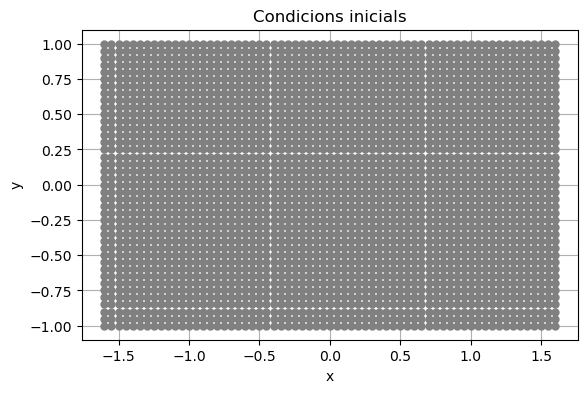

In [942]:
grafica_punts(condicions_inicials, dibuixa_regions=False)

### 2. Generar $n$ trajectòries, una per a cada posició inicial

In [943]:
def generar_trajectories(edo,
                         condicions_inicials: np.ndarray,
                         t_span: Tuple[float, float],
                         t_valors: np.ndarray) -> np.ndarray:
    """
    Paràmetres:
        edo: funció que representa el camp vectorial d'una EDO
        condicions_inicials: llista que conté condicions inicials [x0,y0]
        t_valors: np.array[float], conté els instants de temps on avaluem l'EDO
    
    Cada trajectòria és la solució de l'EDO avaluada en els instants de temps indicats.
    """
    num_trajectories = len(condicions_inicials)
    t_steps = len(t_valors)
    trajectories = np.zeros((num_trajectories, t_steps, dimensio))
    valor_random = np.random.uniform(0, 2)
    args = (valor_random, epsilon, funcio_soroll)
    for i, ci in enumerate(condicions_inicials):
        sol = scipy.integrate.solve_ivp(edo, t_span, ci, t_eval=t_valors, args=args)
        trajectories[i] = sol.y.T
    return trajectories

In [944]:
trajectories = generar_trajectories(edo_duffing, condicions_inicials, t_span, t_valors)
print("(Num trajectories, t_steps, dimensio) =", trajectories.shape)

(Num trajectories, t_steps, dimensio) = (2665, 400, 2)


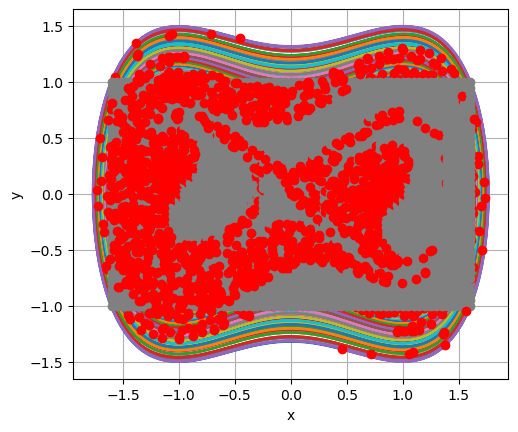

In [945]:
grafica_trajectories(trajectories, dibuixa_regions=False)

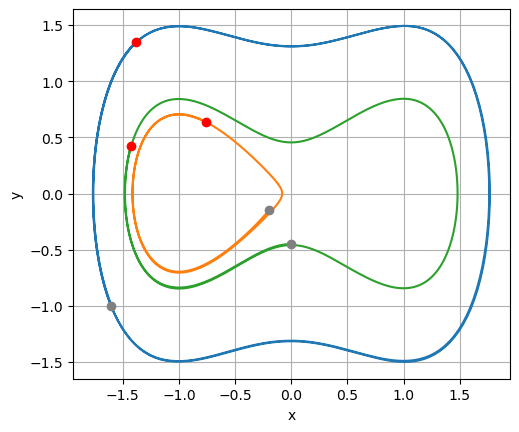

In [946]:
exemples = np.array((trajectories[0], trajectories[1165], trajectories[1323]))
grafica_trajectories(exemples)

### 3. Calcular distàncies $r_{ij}$ entre trajectòries i crear graf $G = (V, E, W)$

Els vèrtexs són cadascuna de les $n$ trajectòries: $V=\{v_1,...,v_n\}$.

Cada aresta $e_{ij}\in E\subseteq V\times V$ està associada al pes $w_{ij}\in W\in\R^{n\times n}$, on $W$ és la matriu de similaritat i $w_{ij} = 1/r_{ij}$. Cada pes representa quant de properes són dues trajectòries ($0 \rightarrow$ poc, i $\infty \rightarrow$ molt).

In [947]:
def calcula_matriu_pesos(trajectories: np.ndarray, t_valors: np.ndarray) -> np.ndarray:
    num_trajectories = trajectories.shape[0]
    t_span_size = t_valors[-1] - t_valors[0]
    matriu_pesos = np.zeros((num_trajectories, num_trajectories))
    for i in range(num_trajectories - 1):
        # Calcula la diferència de la trajectòria 'i' amb totes les 'j > i' alhora
        # trajectories[i] té forma (T, 2), trajectories[i+1:] té forma (N-i-1, T, 2)
        diff = trajectories[i] - trajectories[i+1:]
        # Calcula la norma euclidiana per a cada punt temporal: forma (N-i-1, T)
        norms = np.linalg.norm(diff, axis=2)
        # Integra les distàncies usant la regla del trapezi: forma (N-i-1,)
        distancies = scipy.integrate.trapezoid(norms, x=t_valors, axis=1) / t_span_size
        # Calcula el pes i omple la matriu simètricament
        pesos = 1.0 / distancies
        matriu_pesos[i, i+1:] = pesos
        matriu_pesos[i+1:, i] = pesos
    return matriu_pesos

In [948]:
def calcula_estadistics(matriu_pesos) -> dict[str, float]:
    triangular_upper = matriu_pesos[np.triu_indices(len(matriu_pesos), k=1)]
    percentils = np.percentile(triangular_upper, [0, 50, 90, 95, 100])
    pes_min, pes_mediana, percentil90, percentil95, pes_max = percentils
    estadistics = {
        "pes_min":     pes_min,
        "pes_mediana": pes_mediana,
        "pes_mitja":   np.mean(triangular_upper),
        "percentil90": percentil90,
        "percentil95": percentil95,
        "pes_max":     pes_max
    }
    return estadistics

def imprimeix_estadistics(matriu_pesos: np.ndarray) -> None:
    print(f"Dimensions de la matriu de pesos: {matriu_pesos.shape}")
    estadistics = calcula_estadistics(matriu_pesos)
    for nom, valor in estadistics.items():
        print(f"{nom:<12} {valor:.3f}")

In [949]:
def sparcify_with_tol(matriu: np.ndarray, tol: float) -> Tuple[np.ndarray, float]:
    """Retorna una matriu on els elements més petits que la tolerància es tornen zero.
    Retorna també el percentatge d'esparsificació obtingut.
    Requisit: la diagonal de la matriu ha de ser zero."""
    sota_tolerancia = matriu < tol
    matriu_esparsa = np.where(sota_tolerancia, 0, matriu)
    zeros = np.sum(sota_tolerancia) - len(matriu)  # Excloem la diagonal
    total_elements = matriu.size - len(matriu)  # Excloem la diagonal
    percentatge_esparsificacio = float(zeros / total_elements)
    return matriu_esparsa, percentatge_esparsificacio

def calcula_tol_esparsificacio(matriu: np.ndarray, percent: float) -> float:
    """La tolerància o radi d'esparsificació és el percentil {percent}
    dels valors no nuls de la {matriu}. 
    Com la matriu és simètrica i la diagonal només conté zeros, 
    ens quedem amb la matriu triangular superior sense la diagonal
    """
    triangular_upper = matriu[np.triu_indices(len(matriu), k=1)]
    return float(np.percentile(triangular_upper, percent))

def sparcify(matriu: np.ndarray, percent: float) -> Tuple[np.ndarray, float, float]:
    """Retorna una matriu esparsa on el percentatge escollit dels 
    elements més petits es tornen zero.
    Requisit: la matriu ha de ser simètrica amb diagonal nul·la."""    
    tol = calcula_tol_esparsificacio(matriu, percent)
    matriu_esparsa, sparsification_percent = sparcify_with_tol(matriu, tol)
    return matriu_esparsa, tol, sparsification_percent

### 4 Matriu de similaritat

In [950]:
matriu_pesos = calcula_matriu_pesos(trajectories, t_valors)

In [951]:
imprimeix_estadistics(matriu_pesos)

Dimensions de la matriu de pesos: (2665, 2665)
pes_min      0.295
pes_mediana  0.704
pes_mitja    0.875
percentil90  1.292
percentil95  1.773
pes_max      63.380


In [952]:
matriu_similaritat_W, sparsification_tol, sparsification_percent = \
    sparcify(matriu_pesos, percent=95)
print(f"S'ha obtingut una esparsificació del "
      f"{sparsification_percent*100:.0f}% usant una tolerància de "
      f"{sparsification_tol:.3f}")

S'ha obtingut una esparsificació del 95% usant una tolerància de 1.773


In [953]:
np.fill_diagonal(matriu_similaritat_W, constant_diagonal)
print(matriu_similaritat_W)

[[1000.       5.992    2.961 ...    0.       0.       0.   ]
 [   5.992 1000.       5.786 ...    0.       0.       0.   ]
 [   2.961    5.786 1000.    ...    0.       0.       0.   ]
 ...
 [   0.       0.       0.    ... 1000.       5.786    2.961]
 [   0.       0.       0.    ...    5.786 1000.       5.992]
 [   0.       0.       0.    ...    2.961    5.992 1000.   ]]


### 5. Calcular la matriu diagonal de graus $D$, on $D_{ii}=\sum _{j=0}^{n} w_{ij}$

In [954]:
def calcula_matriu_grau(matriu_similaritat: np.ndarray) -> np.ndarray:
    return np.diag(matriu_similaritat.sum(axis=1))

In [955]:
matriu_grau_D = calcula_matriu_grau(matriu_similaritat_W)

### 6. Descomposició espectral: $Lu =\lambda Du$

In [956]:
def calcula_vaps_veps(matriu_grau_D:        np.ndarray, 
                      matriu_similaritat_W: np.ndarray, 
                      max_clusters:         int):
    """Retorna els VAPs més petits ordenats ascendentment i
    els VEPs del problema generalitzat Lu = lambda Du.
    El paràmetre max_clusters fixa quants VAPs es calculen."""
    matriu_laplacia_L = matriu_grau_D - matriu_similaritat_W
    vaps, veps = scipy.linalg.eigh(matriu_laplacia_L, matriu_grau_D, 
                                   subset_by_index=[0, max_clusters])
    return vaps, veps

In [957]:
vaps, veps = calcula_vaps_veps(matriu_grau_D, matriu_similaritat_W, max_clusters)
print("vaps.shape =", vaps.shape)
print("veps.shape =", veps.shape)

vaps.shape = (41,)
veps.shape = (2665, 41)


In [958]:
vaps = vaps[1:] # eliminem el VAP més petit perquè és zero
print(vaps.shape)

(40,)


### 7. Estimació del nombre de clústers $k$ = argmin [max($g_i$)]

In [ ]:
def calcula_num_clusters(vaps: np.ndarray) -> int:
    """Retorna el nombre de clusters a partir dels VAPs, segons la regla del colze.
    Aquesta regla diu que el nombre de clusters és el valor de k on la diferència
    entre vaps[k] i vaps[k-1] és màxima."""
    diffs = np.diff(vaps)
    num_clusters = np.argmax(diffs)
    # sumem 2 perquè abans hem tret el VAP zero i per 
    # inloure el cluster dels estats incoherents
    return int(num_clusters) + 2

In [ ]:
num_clusters = calcula_num_clusters(vaps)
print("nombre de clusters =", num_clusters)

nombre de clusters = 7


### 8. $k$-means

In [961]:
def troba_clusters(num_clusters: int, veps: np.ndarray) -> np.ndarray:
    matriu_veps_U = veps[:, :num_clusters]
    kmeans = KMeans(n_clusters=num_clusters, n_init=10, random_state=7)
    labels = kmeans.fit_predict(matriu_veps_U)
    return labels

labels = troba_clusters(num_clusters, veps)

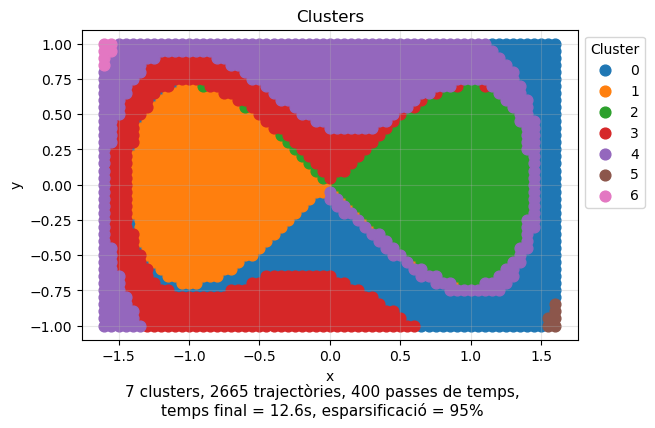

In [962]:
args = (num_clusters, sparsification_tol, sparsification_percent, t_steps, t_span)
grafica_clusters(condicions_inicials, labels, args)